Yanuar Alvin Rifkyarthara
IK-3C/3.34.23.2.25

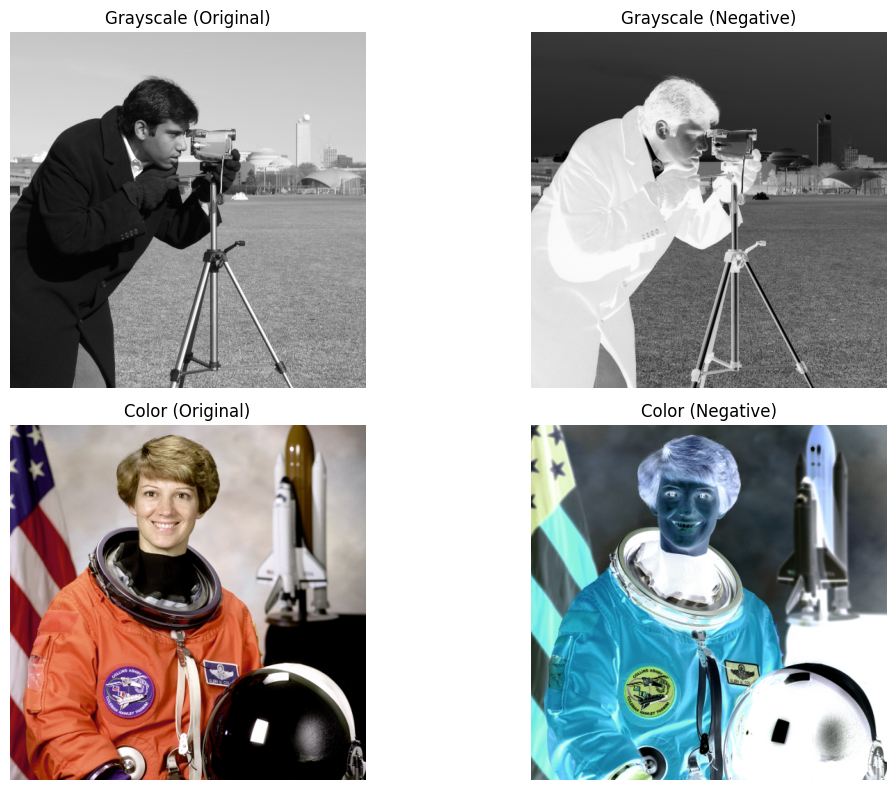

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# ===================
# 1. TRANSFORMASI NEGATIF CITRA GRAYSCALE
# ===================
image_gray_uint8 = data.camera()  # Citra grayscale (512x512, 0..255)
image_gray_float = img_as_float(image_gray_uint8)  # Konversi ke float [0..1]

negative_gray = 1.0 - image_gray_float  # Inversi intensitas

# ===================
# 2. TRANSFORMASI NEGATIF CITRA BERWARNA
# ===================
image_color_uint8 = data.astronaut()  # Citra RGB (512x512x3, 0..255)
image_color_float = img_as_float(image_color_uint8)  # Konversi ke float [0..1]

negative_color = 1.0 - image_color_float  # Inversi tiap channel RGB

# ===================
# 3. PLOTTING HASIL
# ===================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Grayscale
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

# RGB
axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

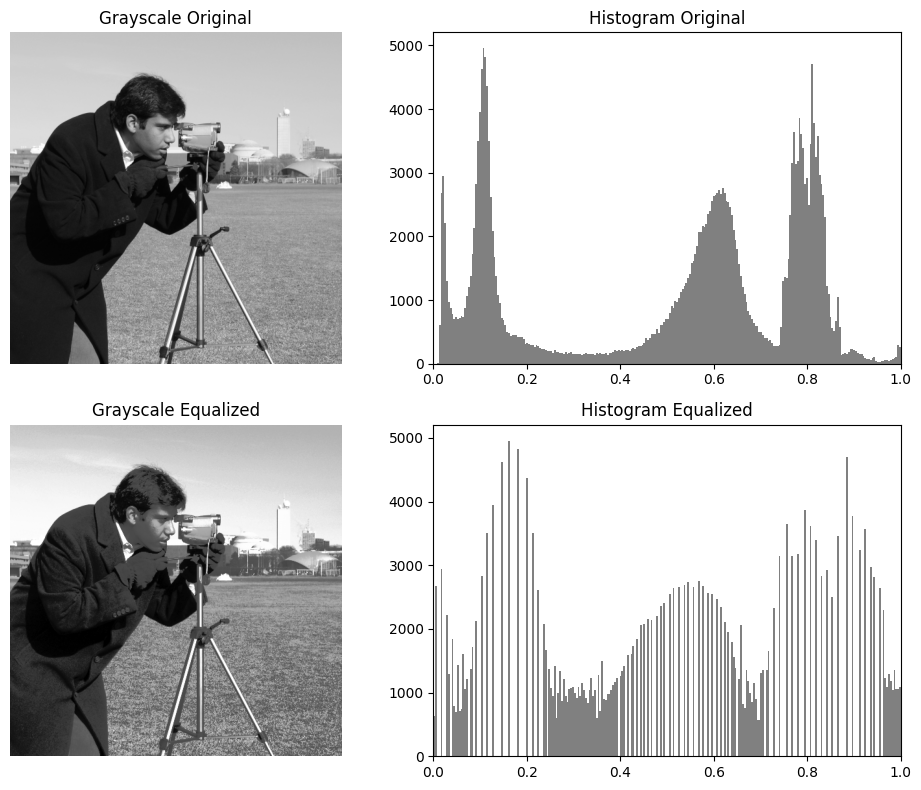

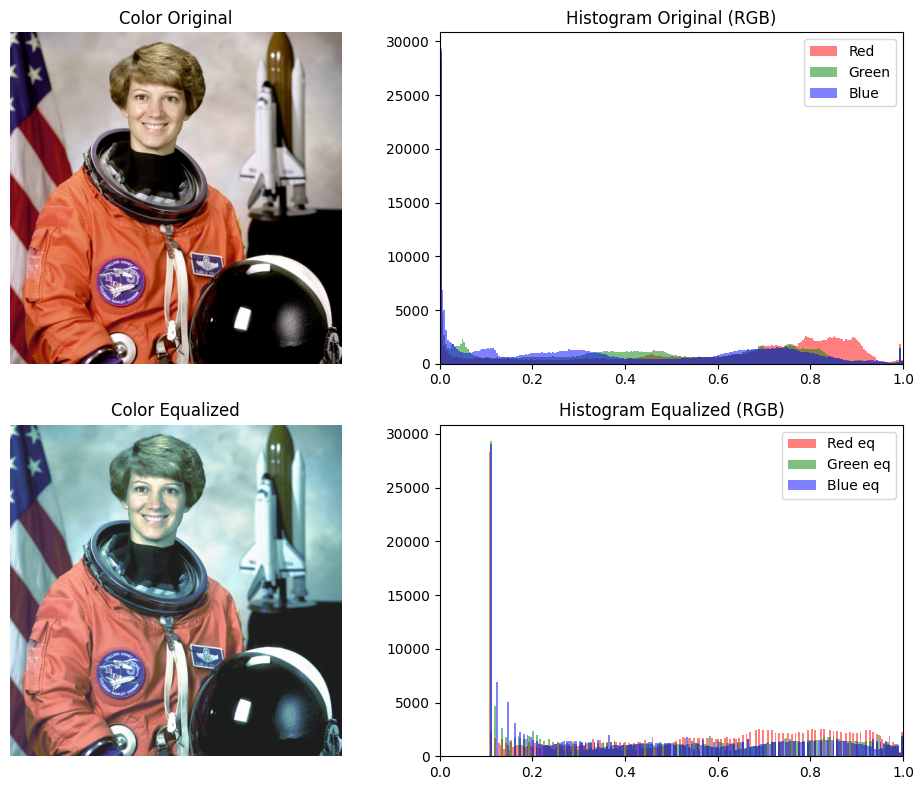

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# ===================
# BAGIAN 1: HISTOGRAM & EKUALISASI (GRAYSCALE)
# ===================

# 1. Load image
image_gray_uint8 = data.camera()
image_gray = img_as_float(image_gray_uint8)

# 2. Histogram asli
hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0,1))

# 3. Ekualisasi
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0,1))

# 4. Plot
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0,1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0,1)

axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0,1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0,1)

plt.tight_layout()
plt.show()

# ===================
# BAGIAN 2: RGB
# ===================

# 1. Load image
image_color_uint8 = data.astronaut()
image_color = img_as_float(image_color_uint8)

# 2. Split channel
r_channel = image_color[:,:,0]
g_channel = image_color[:,:,1]
b_channel = image_color[:,:,2]

# Histogram tiap channel
hist_r, bins_r = np.histogram(r_channel.ravel(), bins=256, range=(0,1))
hist_g, bins_g = np.histogram(g_channel.ravel(), bins=256, range=(0,1))
hist_b, bins_b = np.histogram(b_channel.ravel(), bins=256, range=(0,1))

# 3. Ekualisasi per channel
r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

image_color_eq = np.dstack((r_eq, g_eq, b_eq))

# Histogram hasil
hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), bins=256, range=(0,1))
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), bins=256, range=(0,1))
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), bins=256, range=(0,1))

# 4. Plot
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0,1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0,1)
axes2[0, 1].legend()

axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized")
axes2[1, 0].axis('off')

axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0,1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)")
axes2[1, 1].set_xlim(0,1)
axes2[1, 1].legend()

plt.tight_layout()
plt.show()

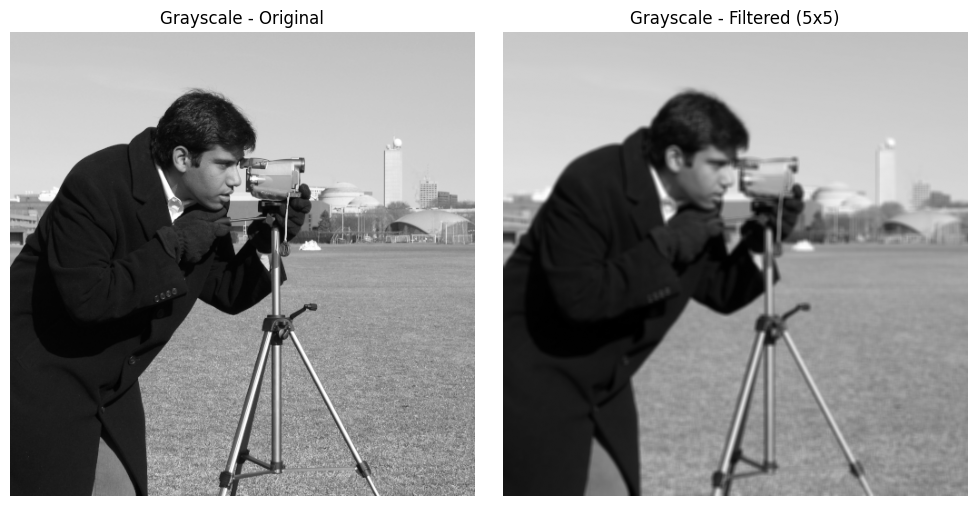

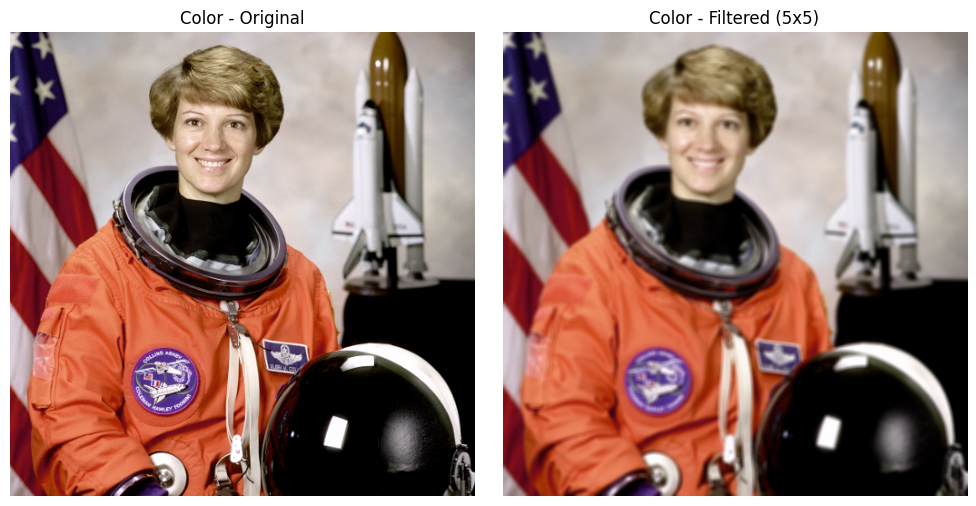

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# ===================
# 1) FILTER RATA-RATA GRAYSCALE
# ===================

# Load image
gray_uint8 = data.camera()
gray_img = img_as_float(gray_uint8)

# Kernel rata-rata 5x5
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

# Konvolusi
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# ===================
# 2) FILTER RATA-RATA RGB
# ===================

# Load image
color_uint8 = data.astronaut()
color_img = img_as_float(color_uint8)

# Siapkan array hasil
color_filtered = np.zeros_like(color_img)

# Konvolusi tiap channel
for c in range(3):
    channel = color_img[:, :, c]
    color_filtered[:, :, c] = ndi.convolve(channel, kernel, mode='reflect')

# Plot
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))

axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size})")
axes2[1].axis('off')

plt.tight_layout()
plt.show()

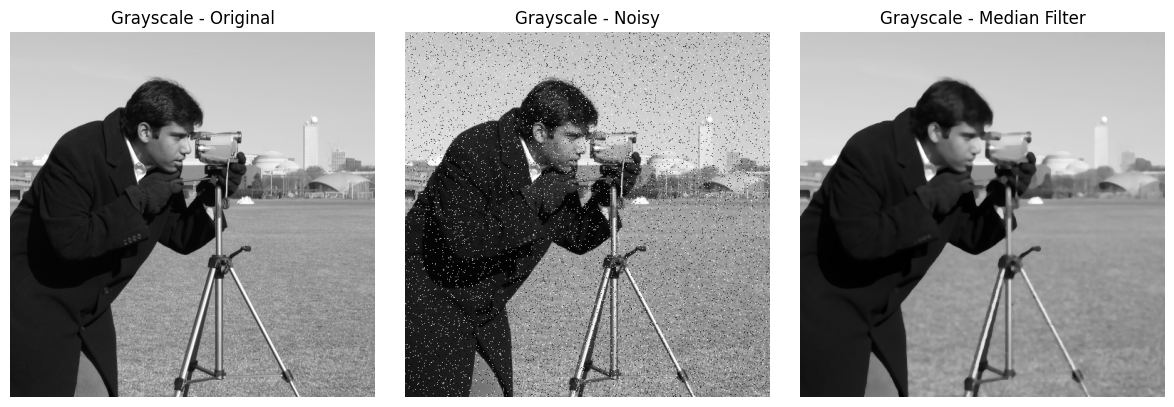

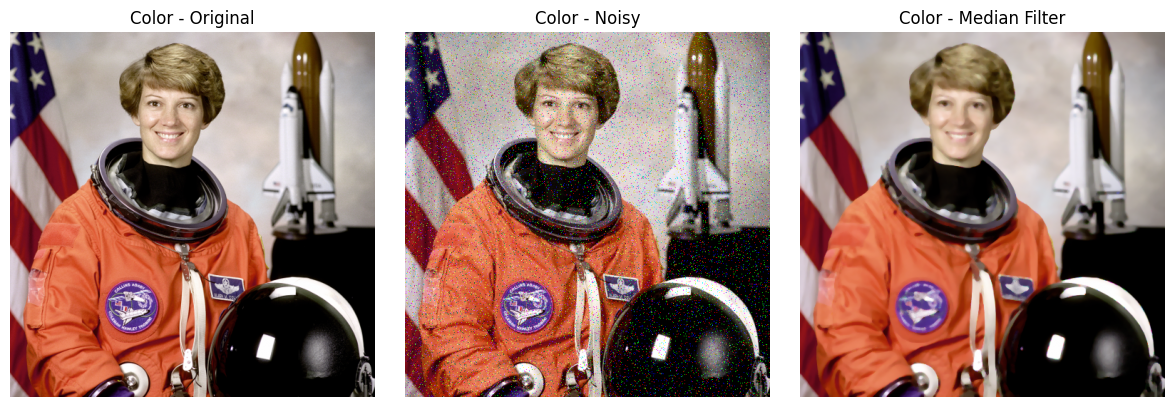

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

# ===================
# 1) MEDIAN FILTER GRAYSCALE
# ===================

# Load image
gray_uint8 = data.camera()
gray_float = img_as_float(gray_uint8)

# Tambah noise salt & pepper
gray_noisy = util.random_noise(gray_float, mode='s&p', amount=0.05)

# Median filter
disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(gray_float, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Grayscale - Noisy")
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Grayscale - Median Filter")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# ===================
# 2) MEDIAN FILTER RGB
# ===================

# Load image
color_uint8 = data.astronaut()
color_float = img_as_float(color_uint8)

# Tambah noise
color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)

# Median per channel
color_denoised = np.zeros_like(color_noisy)

for c in range(3):
    color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

# Plot
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))

axes2[0].imshow(color_float)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title("Color - Noisy")
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title("Color - Median Filter")
axes2[2].axis('off')

plt.tight_layout()
plt.show()

Tugas Nomor 3

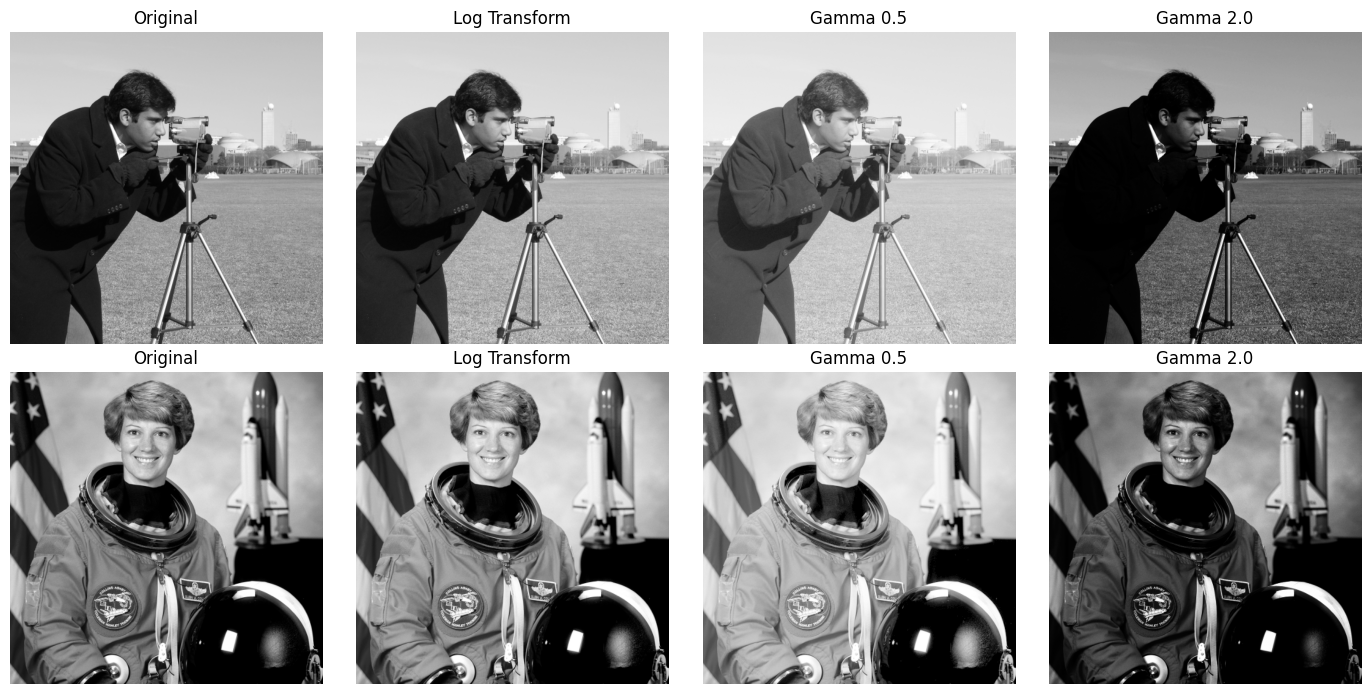

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, img_as_float
from skimage.exposure import adjust_log, adjust_gamma

# ===================
# LOAD CITRA
# ===================
img1 = img_as_float(data.camera())  # grayscale
img2 = img_as_float(color.rgb2gray(data.astronaut()))  # RGB → grayscale

# ===================
# TRANSFORMASI
# ===================

# Log transform
log_img1 = adjust_log(img1)
log_img2 = adjust_log(img2)

# Gamma transform
gamma_low = adjust_gamma(img1, gamma=0.5)   # lebih terang
gamma_high = adjust_gamma(img1, gamma=2.0)  # lebih gelap

# ===================
# PLOT
# ===================
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Baris 1 (camera)
axes[0,0].imshow(img1, cmap='gray')
axes[0,0].set_title("Original")

axes[0,1].imshow(log_img1, cmap='gray')
axes[0,1].set_title("Log Transform")

axes[0,2].imshow(gamma_low, cmap='gray')
axes[0,2].set_title("Gamma 0.5")

axes[0,3].imshow(gamma_high, cmap='gray')
axes[0,3].set_title("Gamma 2.0")

# Baris 2 (astronaut grayscale)
axes[1,0].imshow(img2, cmap='gray')
axes[1,0].set_title("Original")

axes[1,1].imshow(log_img2, cmap='gray')
axes[1,1].set_title("Log Transform")

axes[1,2].imshow(adjust_gamma(img2, gamma=0.5), cmap='gray')
axes[1,2].set_title("Gamma 0.5")

axes[1,3].imshow(adjust_gamma(img2, gamma=2.0), cmap='gray')
axes[1,3].set_title("Gamma 2.0")

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

Tugas Nomor 4

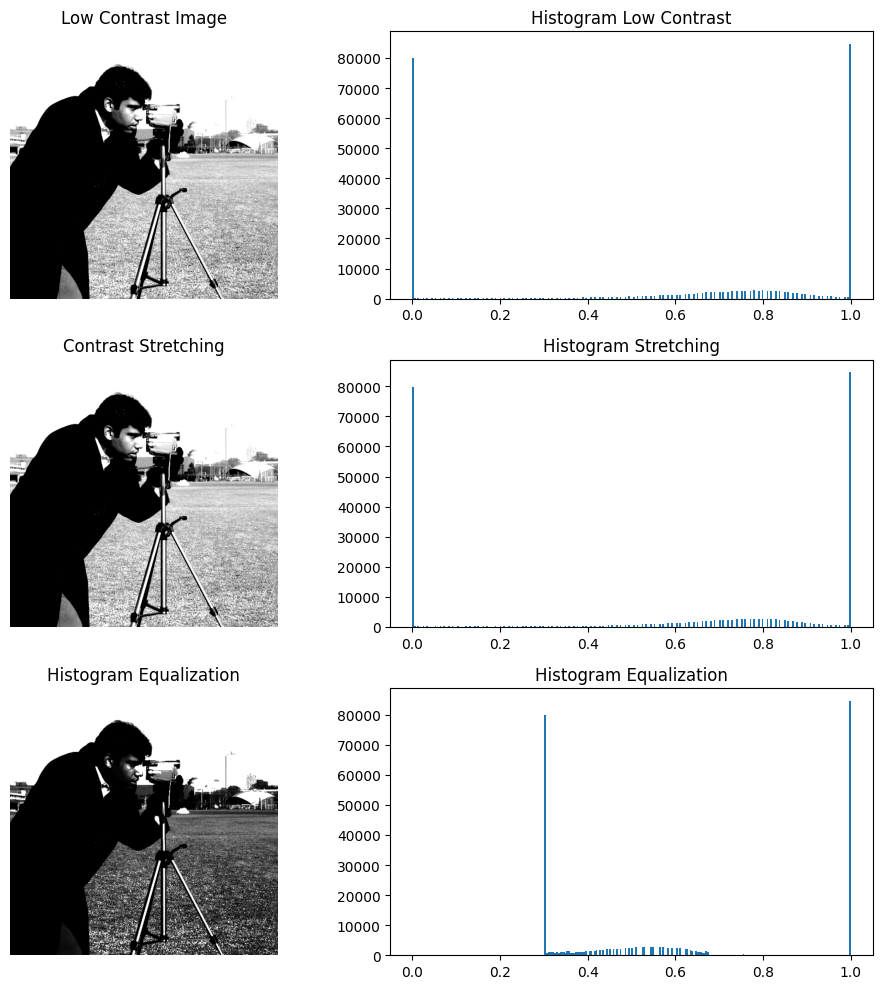

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# ===================
# LOAD CITRA (dibuat low contrast)
# ===================
image = img_as_float(data.camera())

# Buat citra kontras rendah (simulasi)
low_contrast = exposure.rescale_intensity(image, in_range=(0.3, 0.7))

# ===================
# METODE 1: Contrast Stretching
# ===================
stretch = exposure.rescale_intensity(low_contrast, in_range='image', out_range=(0,1))

# ===================
# METODE 2: Histogram Equalization
# ===================
equalized = exposure.equalize_hist(low_contrast)

# ===================
# PLOT
# ===================
fig, axes = plt.subplots(3, 2, figsize=(10, 10))

# Original low contrast
axes[0,0].imshow(low_contrast, cmap='gray')
axes[0,0].set_title("Low Contrast Image")
axes[0,0].axis('off')

axes[0,1].hist(low_contrast.ravel(), bins=256, range=(0,1))
axes[0,1].set_title("Histogram Low Contrast")

# Contrast stretching
axes[1,0].imshow(stretch, cmap='gray')
axes[1,0].set_title("Contrast Stretching")
axes[1,0].axis('off')

axes[1,1].hist(stretch.ravel(), bins=256, range=(0,1))
axes[1,1].set_title("Histogram Stretching")

# Histogram equalization
axes[2,0].imshow(equalized, cmap='gray')
axes[2,0].set_title("Histogram Equalization")
axes[2,0].axis('off')

axes[2,1].hist(equalized.ravel(), bins=256, range=(0,1))
axes[2,1].set_title("Histogram Equalization")

plt.tight_layout()
plt.show()

Tugas Nomor 5

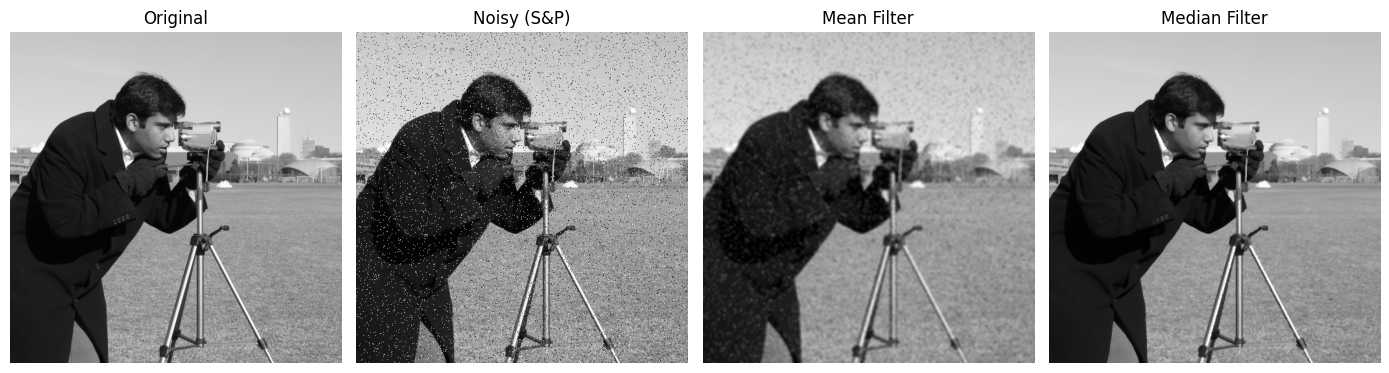

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, img_as_float, filters
from scipy import ndimage as ndi

# ===================
# LOAD CITRA
# ===================
image = img_as_float(data.camera())

# ===================
# TAMBAH NOISE (Salt & Pepper)
# ===================
noisy = util.random_noise(image, mode='s&p', amount=0.05)

# ===================
# FILTER RATA-RATA (Mean Filter)
# ===================
kernel = np.ones((5,5)) / 25
mean_filtered = ndi.convolve(noisy, kernel, mode='reflect')

# ===================
# FILTER MEDIAN
# ===================
median_filtered = filters.median(noisy)

# ===================
# PLOT
# ===================
fig, axes = plt.subplots(1, 4, figsize=(14,4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(noisy, cmap='gray')
axes[1].set_title("Noisy (S&P)")
axes[1].axis('off')

axes[2].imshow(mean_filtered, cmap='gray')
axes[2].set_title("Mean Filter")
axes[2].axis('off')

axes[3].imshow(median_filtered, cmap='gray')
axes[3].set_title("Median Filter")
axes[3].axis('off')

plt.tight_layout()
plt.show()